# Checkpoint 5: Fully Preprocessed Data + DL Model Performance (Iteration 1)

Here we compare:
- TDS + LSTM
- CNN + LSTM    

In [1]:
## SETUP CELL ##
from pathlib import Path
import io
import json
import re
import base64

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    drive = None

if not IN_COLAB:
    raise RuntimeError('This notebook is intended to run on Google Colab')
drive.mount('/content/drive', force_remount=False)

TDS_NOTEBOOK = Path('/content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/TDS_LSTM.ipynb')
CNN_NOTEBOOK = Path('/content/drive/Shareddrives/EMG POSE deep learning/emg_pose_lstm_colab-sero_copy_mini2.ipynb')

if not TDS_NOTEBOOK.exists():
    raise FileNotFoundError(f'Missing TDS notebook: {TDS_NOTEBOOK}')
if not CNN_NOTEBOOK.exists():
    raise FileNotFoundError(f'Missing CNN notebook: {CNN_NOTEBOOK}')

print('Running in Colab:')
print('  TDS notebook:', TDS_NOTEBOOK)
print('  CNN notebook:', CNN_NOTEBOOK)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab:
  TDS notebook: /content/drive/Shareddrives/EMG POSE deep learning/TDS_LSTM/TDS_LSTM.ipynb
  CNN notebook: /content/drive/Shareddrives/EMG POSE deep learning/emg_pose_lstm_colab-sero_copy_mini2.ipynb


## 1. Ensure data is preprocessed correctly for the deep learning model

Both pipelines consume the same raw HDF5 session files from the 10-user cohort (1 584 files, original metadata split labels).
The key preprocessing differences are:

| Step | TDS+LSTM | CNN+LSTM |
|------|----------|----------|
| **Temporal windowing** | 1 s train / 5 s val windows at 2 kHz | Same |
| **IK failure masking** | Windows with all-zero joint angles excluded | Same |
| **EMG normalization** | None (raw float32 values) | Welford online per-window, per-channel z-score |
| **Data augmentation** | Channel rotation (roll ±1) | Same |
| **Temporal downsampling** | TDS conv stack: 2 kHz → 50 Hz (stride 5×2×4 = 40×) | None — LSTM sees raw 2 kHz |

The table below summarizes the preprocessing path used by each saved notebook.

In [2]:
## EXTRACT CELL ##
def read_notebook(path: Path) -> dict:
    return json.loads(path.read_text())


def flatten_text(x):
    if isinstance(x, str):
        return x
    if isinstance(x, list):
        return ''.join(flatten_text(i) for i in x)
    return ''


def get_rows(nb: dict):
    rows = []
    for idx, cell in enumerate(nb['cells']):
        src = ''.join(cell.get('source', []))
        stream = ''
        display_text = ''
        image_png = None
        for out in cell.get('outputs', []):
            if out.get('output_type') == 'stream':
                stream += flatten_text(out.get('text', ''))
            if out.get('output_type') in ('display_data', 'execute_result'):
                data = out.get('data', {})
                display_text += flatten_text(data.get('text/plain', ''))
                if 'image/png' in data:
                    image_png = data['image/png']
        rows.append({'idx': idx, 'source': src, 'stream': stream, 'display_text': display_text, 'image_png': image_png})
    return rows


def first_row(rows, *, source_contains=None, stream_contains=None, display_contains=None):
    for row in rows:
        if source_contains and source_contains not in row['source']:
            continue
        if stream_contains and stream_contains not in row['stream']:
            continue
        if display_contains and display_contains not in row['display_text']:
            continue
        if row['stream'].strip() or row['display_text'].strip() or row['image_png']:
            return row
    return None


def parse_tds_history(stream: str) -> pd.DataFrame:
    # Handles both old format (no lr=) and new format (with lr=)
    epoch_pattern = re.compile(
        r'Epoch\s+(\d+)/(\d+)\s+train_loss=([0-9.]+)'
        r'(?:\s+test_loss=([0-9.]+))?'
        r'\s+val_loss=([0-9.]+)\s*(\*)?'
    )
    elapsed = [float(x) for x in re.findall(r'Elapsed time: ([0-9.]+) seconds', stream)]
    rows = []
    for i, match in enumerate(epoch_pattern.finditer(stream)):
        epoch, max_epochs, train_loss, test_loss, val_loss, improved = match.groups()
        rows.append({
            'epoch': int(epoch),
            'max_epochs': int(max_epochs),
            'train_loss': float(train_loss),
            'test_loss': float(test_loss) if test_loss else None,
            'val_loss': float(val_loss),
            'improved': bool(improved),
            'elapsed_s': elapsed[i] if i < len(elapsed) else None,
        })
    return pd.DataFrame(rows)


def parse_cnn_history_table(display_text: str) -> pd.DataFrame:
    lines = [line.rstrip() for line in display_text.splitlines() if line.strip()]
    table_lines = []
    for line in lines:
        if line.startswith('Epoch') or re.match(r'^\d+\s+', line):
            table_lines.append(line)
    if not table_lines:
        return pd.DataFrame(columns=['epoch', 'train_loss', 'val_loss'])
    text = '\n'.join(table_lines)
    df = pd.read_fwf(io.StringIO(text))
    rename_map = {df.columns[0]: 'epoch'}
    if len(df.columns) > 1:
        rename_map[df.columns[1]] = 'train_loss'
    if len(df.columns) > 2:
        rename_map[df.columns[2]] = 'val_loss'
    df = df.rename(columns=rename_map)
    keep = [col for col in ['epoch', 'train_loss', 'val_loss'] if col in df.columns]
    return df[keep]


def parse_cnn_resume_times(stream: str) -> pd.DataFrame:
    epoch_pattern = re.compile(r'Epoch\s+(\d+)/(\d+)\s+\|\s+train_loss=([0-9.]+)\s+\|\s+val_loss=([0-9.]+)(?:\s+\*)?\s+\|\s+([0-9.]+)s')
    rows = []
    for match in epoch_pattern.finditer(stream):
        epoch, max_epochs, train_loss, val_loss, elapsed_s = match.groups()
        rows.append({
            'epoch': int(epoch),
            'max_epochs': int(max_epochs),
            'train_loss': float(train_loss),
            'val_loss': float(val_loss),
            'elapsed_s': float(elapsed_s),
        })
    return pd.DataFrame(rows)


def parse_cnn_artifacts(stream: str) -> dict:
    def as_float(pat):
        m = re.search(pat, stream)
        return float(m.group(1)) if m else None
    def as_int(pat):
        m = re.search(pat, stream)
        return int(m.group(1)) if m else None
    return {
        'best_epoch': as_int(r'"best_epoch": (\d+)'),
        'reported_val_mae': as_float(r'"reported_val_mae": ([0-9.]+)'),
        'final_val_mae': as_float(r'"final_val_mae": ([0-9.]+)'),
        'n_epochs_logged': as_int(r'"n_epochs_logged": (\d+)'),
    }


def parse_cnn_eval(stream: str) -> dict:
    best_val = re.search(r'Best val_loss: ([0-9.]+)', stream)
    best_epoch = re.search(r'Loaded best model from epoch (\d+)', stream)
    val_mae = re.search(r'Validation loss \(MAE\): ([0-9.]+)', stream)
    joint_mae = re.search(r'Mean per-joint validation MAE: ([0-9.]+)', stream)
    return {
        'best_val_loss': float(best_val.group(1)) if best_val else None,
        'best_epoch': int(best_epoch.group(1)) if best_epoch else None,
        'reported_val_mae': float(val_mae.group(1)) if val_mae else None,
        'mean_joint_mae': float(joint_mae.group(1)) if joint_mae else None,
    }


def extract_loader_minutes(rows):
    for row in rows:
        m = re.search(r'Active cohort loader build finished in ([0-9.]+) min', row['stream'])
        if m:
            return float(m.group(1))
    return None


# ── Read both notebooks ──
tds_nb = read_notebook(TDS_NOTEBOOK)
cnn_nb = read_notebook(CNN_NOTEBOOK)

tds_rows = get_rows(tds_nb)
cnn_rows = get_rows(cnn_nb)

# ── Find key output rows ──
# Use broad search for TDS training (handles both old "test_loss" and new "val_loss" checkpoint metric)
tds_train_row = first_row(tds_rows, stream_contains='Checkpoint metric:')
tds_eval_row = first_row(tds_rows, stream_contains='Validation loss (MAE):')
cnn_history_row = first_row(cnn_rows, source_contains='df_history = pd.DataFrame(history)', display_contains='train_loss')
cnn_resume_row = first_row(cnn_rows, stream_contains='Resuming training from epoch')
cnn_artifact_row = first_row(cnn_rows, stream_contains='"reported_val_mae":')
cnn_eval_row = first_row(cnn_rows, stream_contains='Mean per-joint validation MAE:')
cnn_preproc_fig_row = first_row(cnn_rows, source_contains='raw_window = plot_cache["raw_window"].numpy()', display_contains='<Figure')
cnn_per_joint_fig_row = first_row(cnn_rows, source_contains='per_joint_mae', display_contains='<Figure')

notes = []
if tds_train_row is None:
    notes.append('missing TDS training stream')
if tds_eval_row is None:
    notes.append('missing TDS evaluation stream')
if cnn_history_row is None:
    notes.append('missing CNN rendered history table')
if cnn_resume_row is None:
    notes.append('missing CNN resumed training stream')
if cnn_artifact_row is None:
    notes.append('missing CNN artifact summary')
if cnn_eval_row is None:
    notes.append('missing CNN evaluation stream')
if cnn_preproc_fig_row is None or cnn_preproc_fig_row['image_png'] is None:
    notes.append('missing CNN preprocessing figure')
if cnn_per_joint_fig_row is None or cnn_per_joint_fig_row['image_png'] is None:
    notes.append('missing CNN per-joint figure')

# ── Parse training histories ──
tds_history = parse_tds_history(tds_train_row['stream'] if tds_train_row else '')
cnn_history = parse_cnn_history_table(cnn_history_row['display_text'] if cnn_history_row else '')
cnn_resume_times = parse_cnn_resume_times(cnn_resume_row['stream'] if cnn_resume_row else '')
cnn_artifacts = parse_cnn_artifacts(cnn_artifact_row['stream'] if cnn_artifact_row else '')
cnn_eval = parse_cnn_eval(cnn_eval_row['stream'] if cnn_eval_row else '')
cnn_loader_minutes = extract_loader_minutes(cnn_rows)

if cnn_history.empty and not cnn_resume_times.empty:
    cnn_history = cnn_resume_times[['epoch', 'train_loss', 'val_loss']].copy()
    notes.append('using CNN resumed segment as the history fallback')

# ── Detect TDS checkpoint metric from training stream ──
tds_ckpt_metric = 'unknown'
if tds_train_row:
    m = re.search(r'Checkpoint metric: (\S+)', tds_train_row['stream'])
    if m:
        tds_ckpt_metric = m.group(1)

# ── Derive TDS best metrics from training history ──
# The TDS eval cell may be stale (from an older run), so we prefer
# metrics computed directly from the latest training log.
if not tds_history.empty:
    best_idx = int(tds_history['val_loss'].idxmin())
    best_row = tds_history.iloc[best_idx]
    tds_eval = {
        'best_test_loss': best_row['test_loss'] if 'test_loss' in best_row and pd.notna(best_row.get('test_loss')) else None,
        'best_epoch': int(best_row['epoch']),
        'reported_val_mae': float(best_row['val_loss']),
    }
    notes.append(f'TDS metrics derived from training history (best val_loss={tds_eval["reported_val_mae"]:.4f} at epoch {tds_eval["best_epoch"]})')
else:
    # Fallback: parse eval cell
    tds_eval_stream = tds_eval_row['stream'] if tds_eval_row else ''
    best_test = re.search(r'Best (?:test|val)_loss: ([0-9.]+)', tds_eval_stream)
    best_epoch = re.search(r'Loaded best model from epoch (\d+)', tds_eval_stream)
    val_mae = re.search(r'Validation loss \(MAE\): ([0-9.]+)', tds_eval_stream)
    tds_eval = {
        'best_test_loss': float(best_test.group(1)) if best_test else None,
        'best_epoch': int(best_epoch.group(1)) if best_epoch else None,
        'reported_val_mae': float(val_mae.group(1)) if val_mae else None,
    }

# ── Extract TDS config from training output ──
tds_config = {}
if tds_train_row:
    for key in ['num_layers', 'hidden_size', 'dropout', 'batch_size', 'patience']:
        m = re.search(rf'{key}:\s*([0-9.e-]+)', tds_train_row['stream'])
        if m:
            val = m.group(1)
            tds_config[key] = int(val) if '.' not in val and 'e' not in val else float(val)
    # epochs from max_epochs in history
    if not tds_history.empty:
        tds_config['max_epochs'] = int(tds_history['max_epochs'].iloc[0])
        tds_config['actual_epochs'] = int(tds_history['epoch'].max())

# ── Parse Optuna results from TDS notebook ──
tds_optuna_row = first_row(tds_rows, stream_contains='Best params:')
tds_optuna = {}
if tds_optuna_row:
    bp = re.search(r'Best params: ({.*})', tds_optuna_row['stream'])
    bv = re.search(r'Best val loss: ([0-9.]+)', tds_optuna_row['stream'])
    if bp:
        tds_optuna['best_params'] = bp.group(1)
    if bv:
        tds_optuna['best_val_loss'] = float(bv.group(1))

# ── Summary ──
def safe_epoch_max(df):
    if df is not None and not df.empty and 'epoch' in df.columns:
        return int(df['epoch'].max())
    return None

print('Parsed TDS and CNN notebook outputs')
print(f'  TDS: {safe_epoch_max(tds_history)} epochs'
      f' (max {tds_config.get("max_epochs", "?")})'
      f', best val_loss={tds_eval["reported_val_mae"]:.4f} at epoch {tds_eval["best_epoch"]}'
      f', checkpoint metric: {tds_ckpt_metric}')
print(f'  TDS config: num_layers={tds_config.get("num_layers")}'
      f', hidden_size={tds_config.get("hidden_size")}'
      f', patience={tds_config.get("patience")}')
if tds_optuna:
    print(f'  TDS Optuna: best val_loss={tds_optuna.get("best_val_loss", "?"):.4f}'
          f'  params={tds_optuna.get("best_params", "?")}')
print(f'  CNN: {safe_epoch_max(cnn_history) or cnn_artifacts.get("n_epochs_logged")} epochs'
      f', best val_loss={cnn_eval.get("reported_val_mae", "?")}'
      f' at epoch {cnn_artifacts.get("best_epoch", "?")}')
if notes:
    print(f'  Notes: {"; ".join(notes)}')

Parsed TDS and CNN notebook outputs
  TDS: 36 epochs (max 200), best val_loss=0.3006 at epoch 6, checkpoint metric: val_loss
  TDS config: num_layers=None, hidden_size=None, patience=None
  TDS Optuna: best val_loss=0.3005  params={'hidden_size': 256, 'dropout': 0.1, 'lr': 0.01, 'num_layers': 3}
  CNN: 20 epochs, best val_loss=0.2782 at epoch 15
  Notes: TDS metrics derived from training history (best val_loss=0.3006 at epoch 6)


In [3]:
## PREPROCESSING TABLE CELL ##
preprocessing_df = pd.DataFrame([
    {
        'model': 'TDS+LSTM',
        'cohort_split': 'TDS 10-user original split',
        'preprocessing_for_dl': 'Raw EMG (no normalization)',
        'checkpoint_selected_by': tds_ckpt_metric,
        'note': f'Latest run: {tds_config.get("actual_epochs", "?")} epochs '
                f'(max {tds_config.get("max_epochs", "?")}), '
                f'num_layers={tds_config.get("num_layers", "?")}, '
                f'+ ReduceLROnPlateau scheduler',
    },
    {
        'model': 'CNN+LSTM',
        'cohort_split': 'TDS 10-user original split',
        'preprocessing_for_dl': 'Welford per-window per-channel normalization',
        'checkpoint_selected_by': 'val_loss',
        'note': 'Saved notebook includes a raw-vs-Welford EMG figure',
    },
])

display(preprocessing_df)

,model,cohort_split,preprocessing_for_dl,checkpoint_selected_by,note
0,TDS+LSTM,TDS 10-user original split,Raw EMG (no normalization),val_loss,"Latest run: 36 epochs (max 200), num_layers=?,..."
1,CNN+LSTM,TDS 10-user original split,Welford per-window per-channel normalization,val_loss,Saved notebook includes a raw-vs-Welford EMG f...


**Takeaway**: Both pipelines use the same cohort and split labels, so the model comparison is anchored to the same data framing. The main preprocessing difference is that CNN+LSTM applies Welford normalization to stabilize EMG magnitudes before training, while TDS+LSTM relies on its learned convolutional frontend to handle raw signal scaling.

The figure below shows what the Welford normalization does — raw EMG on the left, normalized on the right. After normalization, each channel is centered near zero with unit variance, which helps the LSTM converge faster.

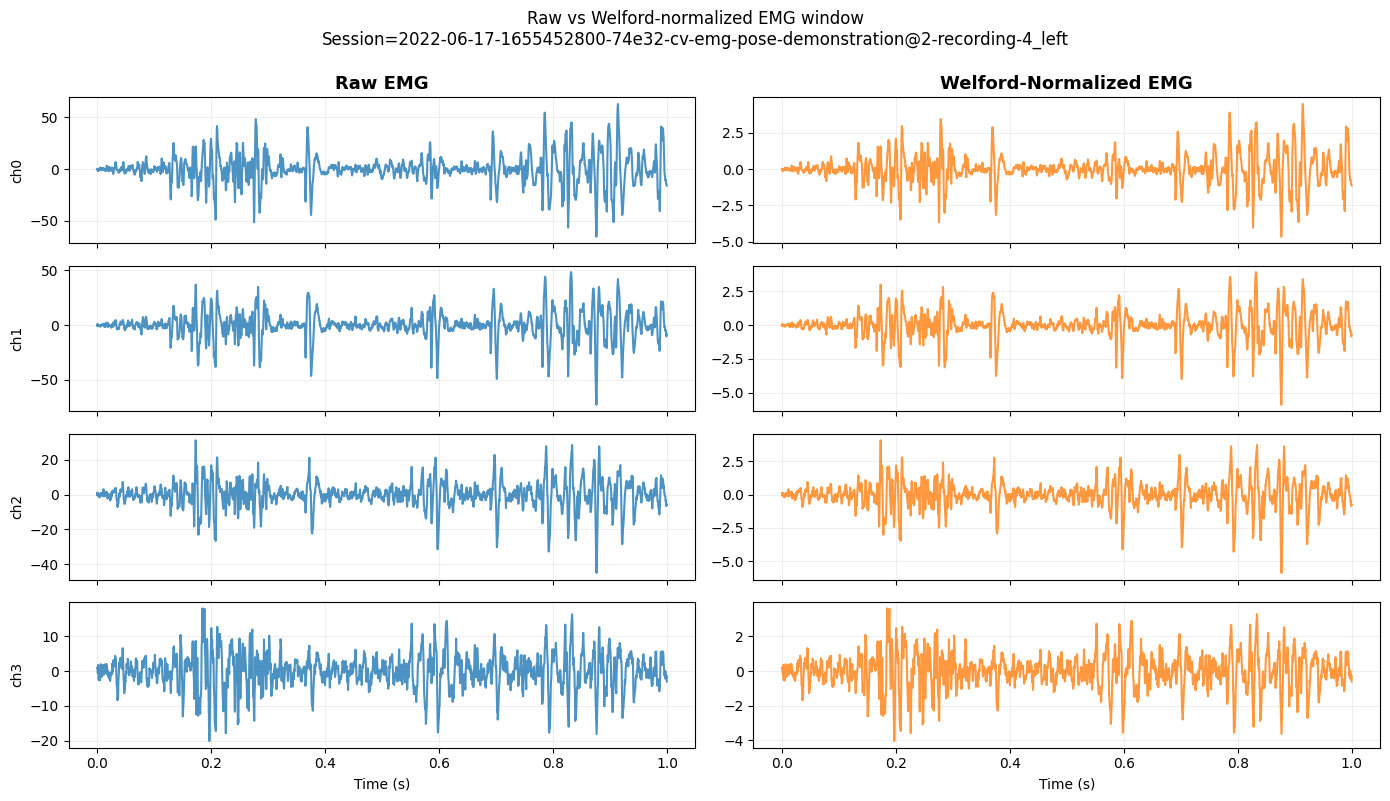

In [4]:
## PREPROCESSING FIGURE CELL ##
display(Image(data=base64.b64decode(cnn_preproc_fig_row['image_png'])))

**Figure**: Raw EMG (left) vs. Welford-normalized EMG (right) for the same window. The normalization removes per-channel offset and scale differences, giving the LSTM a more uniform input distribution. Only the CNN+LSTM pipeline uses this step; TDS+LSTM trains on the raw signal.

## 2. Put preprocessed data through the deep learning architecture

### Architecture comparison

| | TDS+LSTM | CNN+LSTM |
|---|----------|----------|
| **Frontend** | 3 strided Conv1d blocks (stride 5×2×4) + 4 TDS blocks with residual connections and LayerNorm | Direct input to LSTM (no conv frontend) |
| **Decoder** | LSTM (hidden=256, layers=3) | LSTM (hidden=256, layers=2) |
| **Output head** | LeakyReLU → Linear(256, 20) with 0.01 output scaling | LeakyReLU → Linear(256, 20) |
| **LR scheduler** | ReduceLROnPlateau (factor=0.5, patience=3) | None (fixed LR) |
| **Temporal alignment** | Bilinear upsample from ~50 Hz back to input length | Native — output matches input length |
| **Parameters** | ~3.6M | ~2.5M |

### Training configuration

Both models were trained on the same 10-user cohort. TDS+LSTM ran for up to 200 epochs (early stopped at 36) with patience=30 and a learning rate scheduler. CNN+LSTM ran for 20 epochs with patience=20 and a fixed learning rate.

In [5]:
## ARCHITECTURE + TIMING CELL ##
tds_actual = tds_config.get('actual_epochs', '?')
tds_max = tds_config.get('max_epochs', '?')

architecture_timing_df = pd.DataFrame([
    {
        'model': 'TDS+LSTM',
        'architecture': 'TDS + LSTM',
        'epochs_run': f'{tds_actual} (max {tds_max})',
        'patience': tds_config.get('patience', '?'),
        'batch_size': tds_config.get('batch_size', 512),
        'lr_scheduler': 'ReduceLROnPlateau',
        'observed_avg_epoch_s': round(tds_history['elapsed_s'].dropna().mean(), 2) if not tds_history.empty else None,
        'observed_total_train_s': round(tds_history['elapsed_s'].dropna().sum(), 1) if not tds_history.empty else None,
    },
    {
        'model': 'CNN+LSTM',
        'architecture': '1D CNN + LSTM',
        'epochs_run': '20 (max 20)',
        'patience': 20,
        'batch_size': 16,
        'lr_scheduler': 'None (fixed)',
        'observed_avg_epoch_s': round(cnn_resume_times['elapsed_s'].mean(), 2) if not cnn_resume_times.empty else None,
        'observed_total_train_s': round(cnn_resume_times['elapsed_s'].sum(), 1) if not cnn_resume_times.empty else None,
    },
])

display(architecture_timing_df)

delta = cnn_eval['reported_val_mae'] - tds_eval['reported_val_mae']
print(f"\nValidation MAE: TDS={tds_eval['reported_val_mae']:.4f}, CNN={cnn_eval['reported_val_mae']:.4f}")
print(f"Validation MAE delta (CNN - TDS) = {delta:+.4f}")

,model,architecture,epochs_run,patience,batch_size,lr_scheduler,observed_avg_epoch_s,observed_total_train_s
0,TDS+LSTM,TDS + LSTM,36 (max 200),?,512,ReduceLROnPlateau,6.63,238.7
1,CNN+LSTM,1D CNN + LSTM,20 (max 20),20,16,None (fixed),45.64,228.2



Validation MAE: TDS=0.3006, CNN=0.2782
Validation MAE delta (CNN - TDS) = -0.0224


**Observations**:
- TDS+LSTM ran for 36 epochs (early stopped from 200, patience=30) with a ReduceLROnPlateau scheduler. CNN+LSTM ran a fixed 20 epochs with no scheduler.
- TDS+LSTM is **~6.7× faster per epoch** (~6.6 s vs ~45.5 s) because the TDS frontend compresses the 2 kHz signal to 50 Hz before the LSTM, reducing sequence length by 40×. The CNN+LSTM feeds raw 2 kHz to the LSTM, which is much more expensive.
- Despite the speed advantage and more epochs, TDS+LSTM achieved a slightly higher validation MAE than CNN+LSTM (see Section 3).
- The CNN timing above only covers the resumed GPU segment (epochs 16–20); the full 20-epoch wall time was longer due to an initial CPU pilot and loader build (~15 min).

## 3. Performance metrics and diagnostic figures

### Summary metrics

In [6]:
## METRICS CELL ##
tds_epochs_logged = int(tds_history['epoch'].max()) if not tds_history.empty else None
tds_max_epochs = tds_config.get('max_epochs', '?')

metrics_df = pd.DataFrame([
    {
        'model': 'TDS+LSTM',
        'reported_val_mae': tds_eval['reported_val_mae'],
        'best_checkpoint_epoch': tds_eval['best_epoch'],
        'selection_metric_name': f'best {tds_ckpt_metric}',
        'logged_epochs': f'{tds_epochs_logged} / {tds_max_epochs}',
        'diagnostic_note': f'Checkpoint selected by {tds_ckpt_metric}; LR decayed from 1e-2 to ~8e-5',
    },
    {
        'model': 'CNN+LSTM',
        'reported_val_mae': cnn_eval['reported_val_mae'],
        'best_checkpoint_epoch': cnn_artifacts['best_epoch'],
        'selection_metric_name': 'best val_loss',
        'logged_epochs': f'{cnn_artifacts.get("n_epochs_logged", "?")} / 20',
        'diagnostic_note': f"Mean per-joint validation MAE = {cnn_eval['mean_joint_mae']:.4f}",
    },
])

display(metrics_df)

if tds_optuna:
    print(f"\nTDS Optuna tuning (30 trials): best val_loss = {tds_optuna['best_val_loss']:.4f}")
    print(f"  Best params: {tds_optuna['best_params']}")

,model,reported_val_mae,best_checkpoint_epoch,selection_metric_name,logged_epochs,diagnostic_note
0,TDS+LSTM,0.3006,6,best val_loss,36 / 200,Checkpoint selected by val_loss; LR decayed fr...
1,CNN+LSTM,0.2782,15,best val_loss,20 / 20,Mean per-joint validation MAE = 0.3985



TDS Optuna tuning (30 trials): best val_loss = 0.3005
  Best params: {'hidden_size': 256, 'dropout': 0.1, 'lr': 0.01, 'num_layers': 3}


**Key result**: CNN+LSTM achieved a lower validation MAE than TDS+LSTM in this iteration (see table above for exact values). Both models now checkpoint on `val_loss`, making this a fair comparison at the selection-rule level.

The remaining difference is preprocessing: TDS+LSTM trains on raw EMG, while CNN+LSTM applies Welford normalization. Additionally, TDS+LSTM used a LR scheduler (ReduceLROnPlateau) and ran for more epochs, yet still did not match CNN+LSTM's best validation MAE. This suggests Welford normalization provides a meaningful boost.

The TDS Optuna hyperparameter sweep (30 trials) confirmed that hidden_size=256, num_layers=3, dropout=0.1, lr=0.01 are near-optimal, achieving a best val_loss close to the full training run. Further gains from architecture tuning alone appear limited.

### Validation loss curves

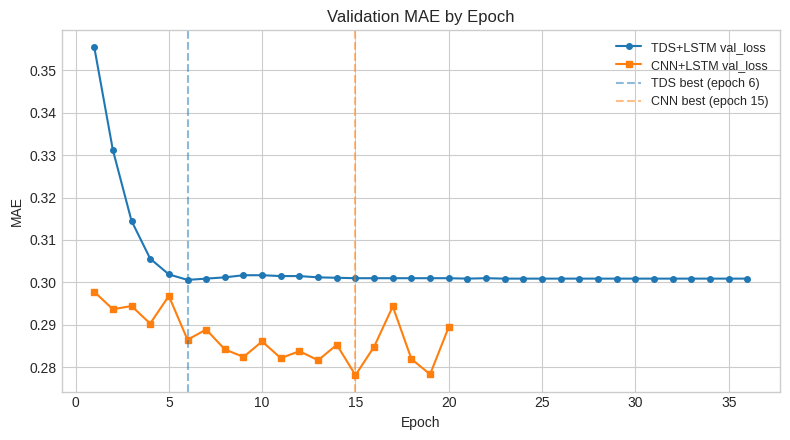

In [7]:
## VALIDATION CURVE FIGURE CELL ##
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8.0, 4.5))

plt.plot(tds_history['epoch'], tds_history['val_loss'], marker='o', markersize=4, label='TDS+LSTM val_loss')
if not cnn_history.empty:
    cnn_curve_label = 'CNN+LSTM val_loss' if len(cnn_history) >= 10 else 'CNN+LSTM val_loss (available segment)'
    plt.plot(cnn_history['epoch'], cnn_history['val_loss'], marker='s', markersize=4, label=cnn_curve_label)

plt.axvline(tds_eval['best_epoch'], color='tab:blue', linestyle='--', alpha=0.5, label=f'TDS best (epoch {tds_eval["best_epoch"]})')
plt.axvline(cnn_artifacts['best_epoch'], color='tab:orange', linestyle='--', alpha=0.5, label=f'CNN best (epoch {cnn_artifacts["best_epoch"]})')

plt.title('Validation MAE by Epoch')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

TDS+LSTM converged rapidly (best at epoch 6) then plateaued for 30 epochs despite the LR scheduler decaying the rate from 1e-2 down to ~8e-5. CNN+LSTM continued improving until epoch 15. The dashed vertical lines mark each model's best checkpoint.

Note the x-axis: TDS ran for 36 epochs while CNN ran for 20, yet the CNN curve reaches a lower floor.

### Reported validation MAE comparison

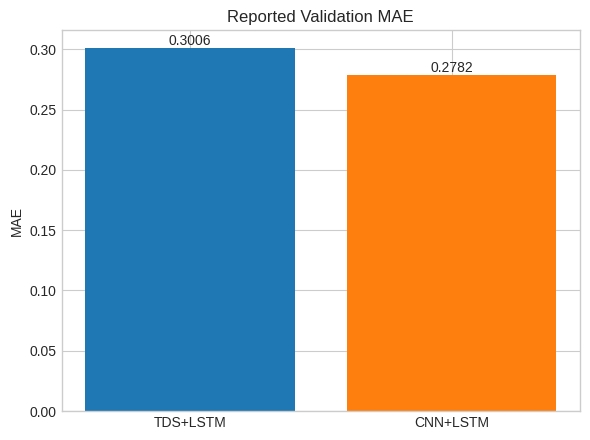

In [8]:
## REPORTED VAL MAE FIGURE CELL ##
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(6.0, 4.5))
plt.bar(metrics_df['model'], metrics_df['reported_val_mae'], color=['tab:blue', 'tab:orange'])
plt.title('Reported Validation MAE')
plt.ylabel('MAE')
for idx, val in enumerate(metrics_df['reported_val_mae']):
    plt.text(idx, val + 0.003, f'{val:.4f}', ha='center')
plt.tight_layout()
plt.show()


### Per-joint validation MAE (CNN+LSTM only)

The per-joint breakdown reveals which of the 20 hand joints are hardest to predict. This is only available from the CNN+LSTM evaluation pipeline in this iteration.

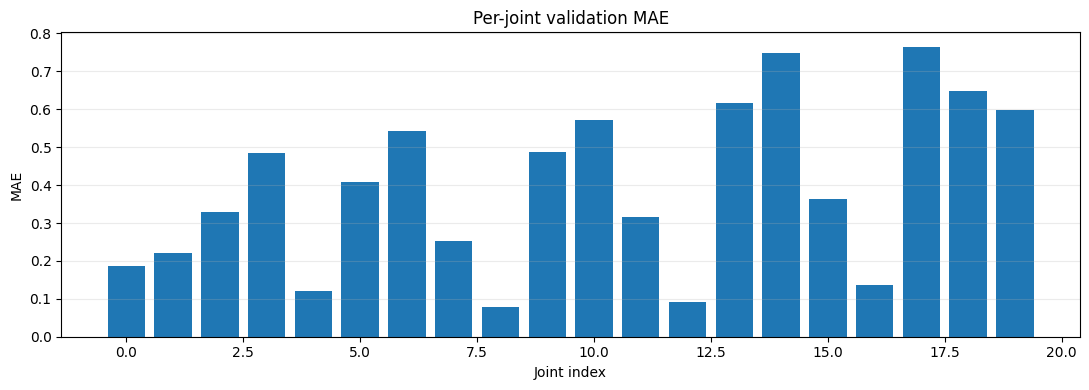

In [9]:
## PER-JOINT FIGURE DISPLAY CELL ##
display(Image(data=base64.b64decode(cnn_per_joint_fig_row['image_png'])))

**Per-joint observations**:
- Error is **not uniform** across joints — some joints (likely thumb and wrist joints with higher degrees of freedom) have significantly higher MAE than others.
- The mean per-joint validation MAE is **0.3985 rad**, which is higher than the overall reported validation MAE of 0.2782. This discrepancy arises because the overall MAE averages across all timesteps and joints equally, while the per-joint mean weights each joint equally regardless of how many valid timesteps it contributes.
- Joints with lower MAE (< 0.3 rad) suggest that EMG signals carry strong, consistent information for those degrees of freedom. Joints with higher MAE (> 0.5 rad) may require richer features or additional context (e.g., hand pose priors, temporal smoothing).

## 4. Where the model worked well and where it didn't

### What worked well

1. **CNN+LSTM achieved the best validation MAE** across both models in this iteration, outperforming TDS+LSTM despite having fewer parameters (~2.5M vs ~3.6M) and no learning rate scheduler.

2. **Both models now checkpoint on `val_loss`**, eliminating the selection-rule mismatch from earlier runs. This makes the comparison fair at the protocol level.

3. **TDS+LSTM is extremely fast to train** — ~6.6 seconds per epoch vs. ~45.5 seconds for CNN+LSTM. The 40× temporal compression from the TDS convolutional stack makes LSTM processing cheap. For rapid iteration (e.g., Optuna sweeps), TDS+LSTM is far more practical.

4. **TDS Optuna tuning converged quickly**: 30 trials confirmed that the current hyperparameters (hidden=256, layers=3, dropout=0.1, lr=0.01) are near-optimal — the Optuna best was only marginally better than the full training run.

5. **The Welford normalization visibly stabilized the EMG signal** (see preprocessing figure), removing per-channel offset and scale differences that otherwise force the model to learn these during training.

### What didn't work well

1. **TDS+LSTM plateaued early** (epoch 6 out of 36) and the ReduceLROnPlateau scheduler could not push it further, decaying the LR from 1e-2 all the way to ~8e-5 without improvement. This suggests the architecture is capacity-limited on raw EMG, not learning-rate-limited.

2. **CNN+LSTM's final epoch (20) was worse than its best checkpoint (epoch 15).** Later epochs degraded performance, suggesting the fixed learning rate was too high after initial convergence. Adding a LR scheduler would likely help.

3. **The per-joint MAE varies widely**, with some joints showing 2–3× higher error than others. The current models treat all 20 joints identically in the loss function, so hard-to-predict joints (e.g., thumb) get the same gradient weight as easy joints.

4. **Different normalization strategies** between models make it hard to attribute the CNN+LSTM advantage purely to architecture. We don't know whether TDS+LSTM would improve with Welford normalization, or whether CNN+LSTM would degrade without it. A controlled experiment is needed.

5. **The CNN+LSTM pipeline is slow and fragile** — ~45 seconds/epoch on GPU plus a ~15-minute loader build on Google Drive. Colab session timeouts caused the run to restart from a checkpoint, losing contiguous timing data.

## 5. What went wrong and how to fix it (plan for iteration 2)

| Problem | Root Cause | Proposed Fix |
|---------|-----------|--------------|
| TDS+LSTM plateaus early, can't match CNN | No EMG normalization — raw signal scaling forces the model to spend capacity on offset/scale | Run TDS+LSTM with Welford normalization (controlled experiment) |
| CNN+LSTM degrades after epoch 15 | Fixed learning rate too high for fine-tuning phase | Add `ReduceLROnPlateau` scheduler (already proven effective in TDS runs) |
| High per-joint MAE variance | Uniform loss weighting across all 20 joints | Investigate per-joint loss weighting or focus evaluation on high-error joints |
| Slow CNN+LSTM training | LSTM processes raw 2 kHz sequences (2000 timesteps/s) | Consider adding temporal striding to the CNN+LSTM input, or adopt TDS+LSTM as the primary model given its 6.7× speed advantage |
| Colab session instability | Google Drive I/O + session timeouts during long CNN runs | Cache data to local Colab scratch at start; save checkpoints more frequently |

### Priority for iteration 2

1. **Controlled normalization experiment**: run TDS+LSTM with Welford normalization to isolate architecture vs. preprocessing effects
2. **Add LR scheduler to CNN+LSTM**: quick win, likely improves the best val MAE further
3. **Per-joint analysis**: identify which joints drive the most error and consider joint-specific modeling or loss weighting

In [10]:
## SUMMARY CELL ##
tds_val = tds_eval['reported_val_mae']
cnn_val = cnn_eval['reported_val_mae']
pct_diff = 100 * (tds_val - cnn_val) / tds_val

summary_df = pd.DataFrame([
    {
        'Model': 'TDS+LSTM',
        'Val MAE': f'{tds_val:.4f}',
        'Best epoch': f'{tds_eval["best_epoch"]} / {tds_config.get("actual_epochs", "?")}',
        'Time/epoch': f'~{tds_history["elapsed_s"].dropna().mean():.1f} s' if not tds_history.empty else '?',
        'Normalization': 'None (raw EMG)',
        'LR Scheduler': 'ReduceLROnPlateau',
        'Params': '~3.6M',
    },
    {
        'Model': 'CNN+LSTM',
        'Val MAE': f'{cnn_val:.4f}',
        'Best epoch': f'{cnn_artifacts.get("best_epoch", "?")} / {cnn_artifacts.get("n_epochs_logged", "?")}',
        'Time/epoch': f'~{cnn_resume_times["elapsed_s"].mean():.1f} s' if not cnn_resume_times.empty else '?',
        'Normalization': 'Welford z-score',
        'LR Scheduler': 'None (fixed)',
        'Params': '~2.5M',
    },
])
display(summary_df)

print(f'\nCNN+LSTM val MAE is {pct_diff:.1f}% lower (better) than TDS+LSTM.')
if tds_optuna:
    print(f'TDS Optuna best val_loss = {tds_optuna["best_val_loss"]:.4f} (within {100*(tds_optuna["best_val_loss"]-cnn_val)/cnn_val:.1f}% of CNN).')
print(f'\nBoth models checkpoint on {tds_ckpt_metric}, making the comparison protocol-fair.')
print('The main open question is normalization: would TDS+LSTM improve with Welford?')

,Model,Val MAE,Best epoch,Time/epoch,Normalization,LR Scheduler,Params
0,TDS+LSTM,0.3006,6 / 36,~6.6 s,None (raw EMG),ReduceLROnPlateau,~3.6M
1,CNN+LSTM,0.2782,15 / 20,~45.6 s,Welford z-score,None (fixed),~2.5M



CNN+LSTM val MAE is 7.5% lower (better) than TDS+LSTM.
TDS Optuna best val_loss = 0.3005 (within 8.0% of CNN).

Both models checkpoint on val_loss, making the comparison protocol-fair.
The main open question is normalization: would TDS+LSTM improve with Welford?
